In [1]:
from pathlib import Path
from zipfile import ZipFile
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

BASE_DIR = Path.cwd()
DELAY_FILE = BASE_DIR / "Delay_distribution.xlsx"
MAKECOST_FILE = BASE_DIR / "MakeCost.xlsx"
STATION_FILE = BASE_DIR / "StationProcessing.xlsx"

# Use one shared size so both figures match in Overleaf.
FIGSIZE = (18, 12)
DPI = 300

plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

In [2]:
NS = {"main": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}


def excel_col_to_index(cell_ref):
    letters = "".join(ch for ch in cell_ref if ch.isalpha())
    index = 0
    for char in letters:
        index = index * 26 + (ord(char.upper()) - ord("A") + 1)
    return index - 1


def parse_cell_value(cell, shared_strings):
    value = cell.find("main:v", NS)
    if value is None:
        return ""
    raw = value.text
    if cell.get("t") == "s":
        return shared_strings[int(raw)]
    try:
        number = float(raw)
        return int(number) if number.is_integer() else number
    except ValueError:
        return raw


def read_simple_xlsx(path):
    with ZipFile(path) as workbook:
        shared_strings = []
        if "xl/sharedStrings.xml" in workbook.namelist():
            shared_root = ET.fromstring(workbook.read("xl/sharedStrings.xml"))
            for string_item in shared_root.findall("main:si", NS):
                text = "".join(node.text or "" for node in string_item.iterfind(".//main:t", NS))
                shared_strings.append(text)

        sheet_root = ET.fromstring(workbook.read("xl/worksheets/sheet1.xml"))
        rows = []
        for row in sheet_root.find("main:sheetData", NS).findall("main:row", NS):
            row_values = {}
            max_col = -1
            for cell in row.findall("main:c", NS):
                col_index = excel_col_to_index(cell.get("r", "A1"))
                row_values[col_index] = parse_cell_value(cell, shared_strings)
                max_col = max(max_col, col_index)
            rows.append([row_values.get(i, "") for i in range(max_col + 1)])
        return rows


delay_rows = read_simple_xlsx(DELAY_FILE)
makecost_rows = read_simple_xlsx(MAKECOST_FILE)

delay_rows[:3], makecost_rows[:3]

([['Delay Category', 'Initial Solution', 1, 2, 3],
  ['On Time', 28.0384397964951, 72.9225551158846, 100, 100],
  ['0-6h', 5.70944036178632, 2.65686828716789, 0, 0]],
 [['Run ID', 'Makespan ', 'Cost'],
  ['Initial Solution', 66, 30720],
  [1, 58, 31200]])

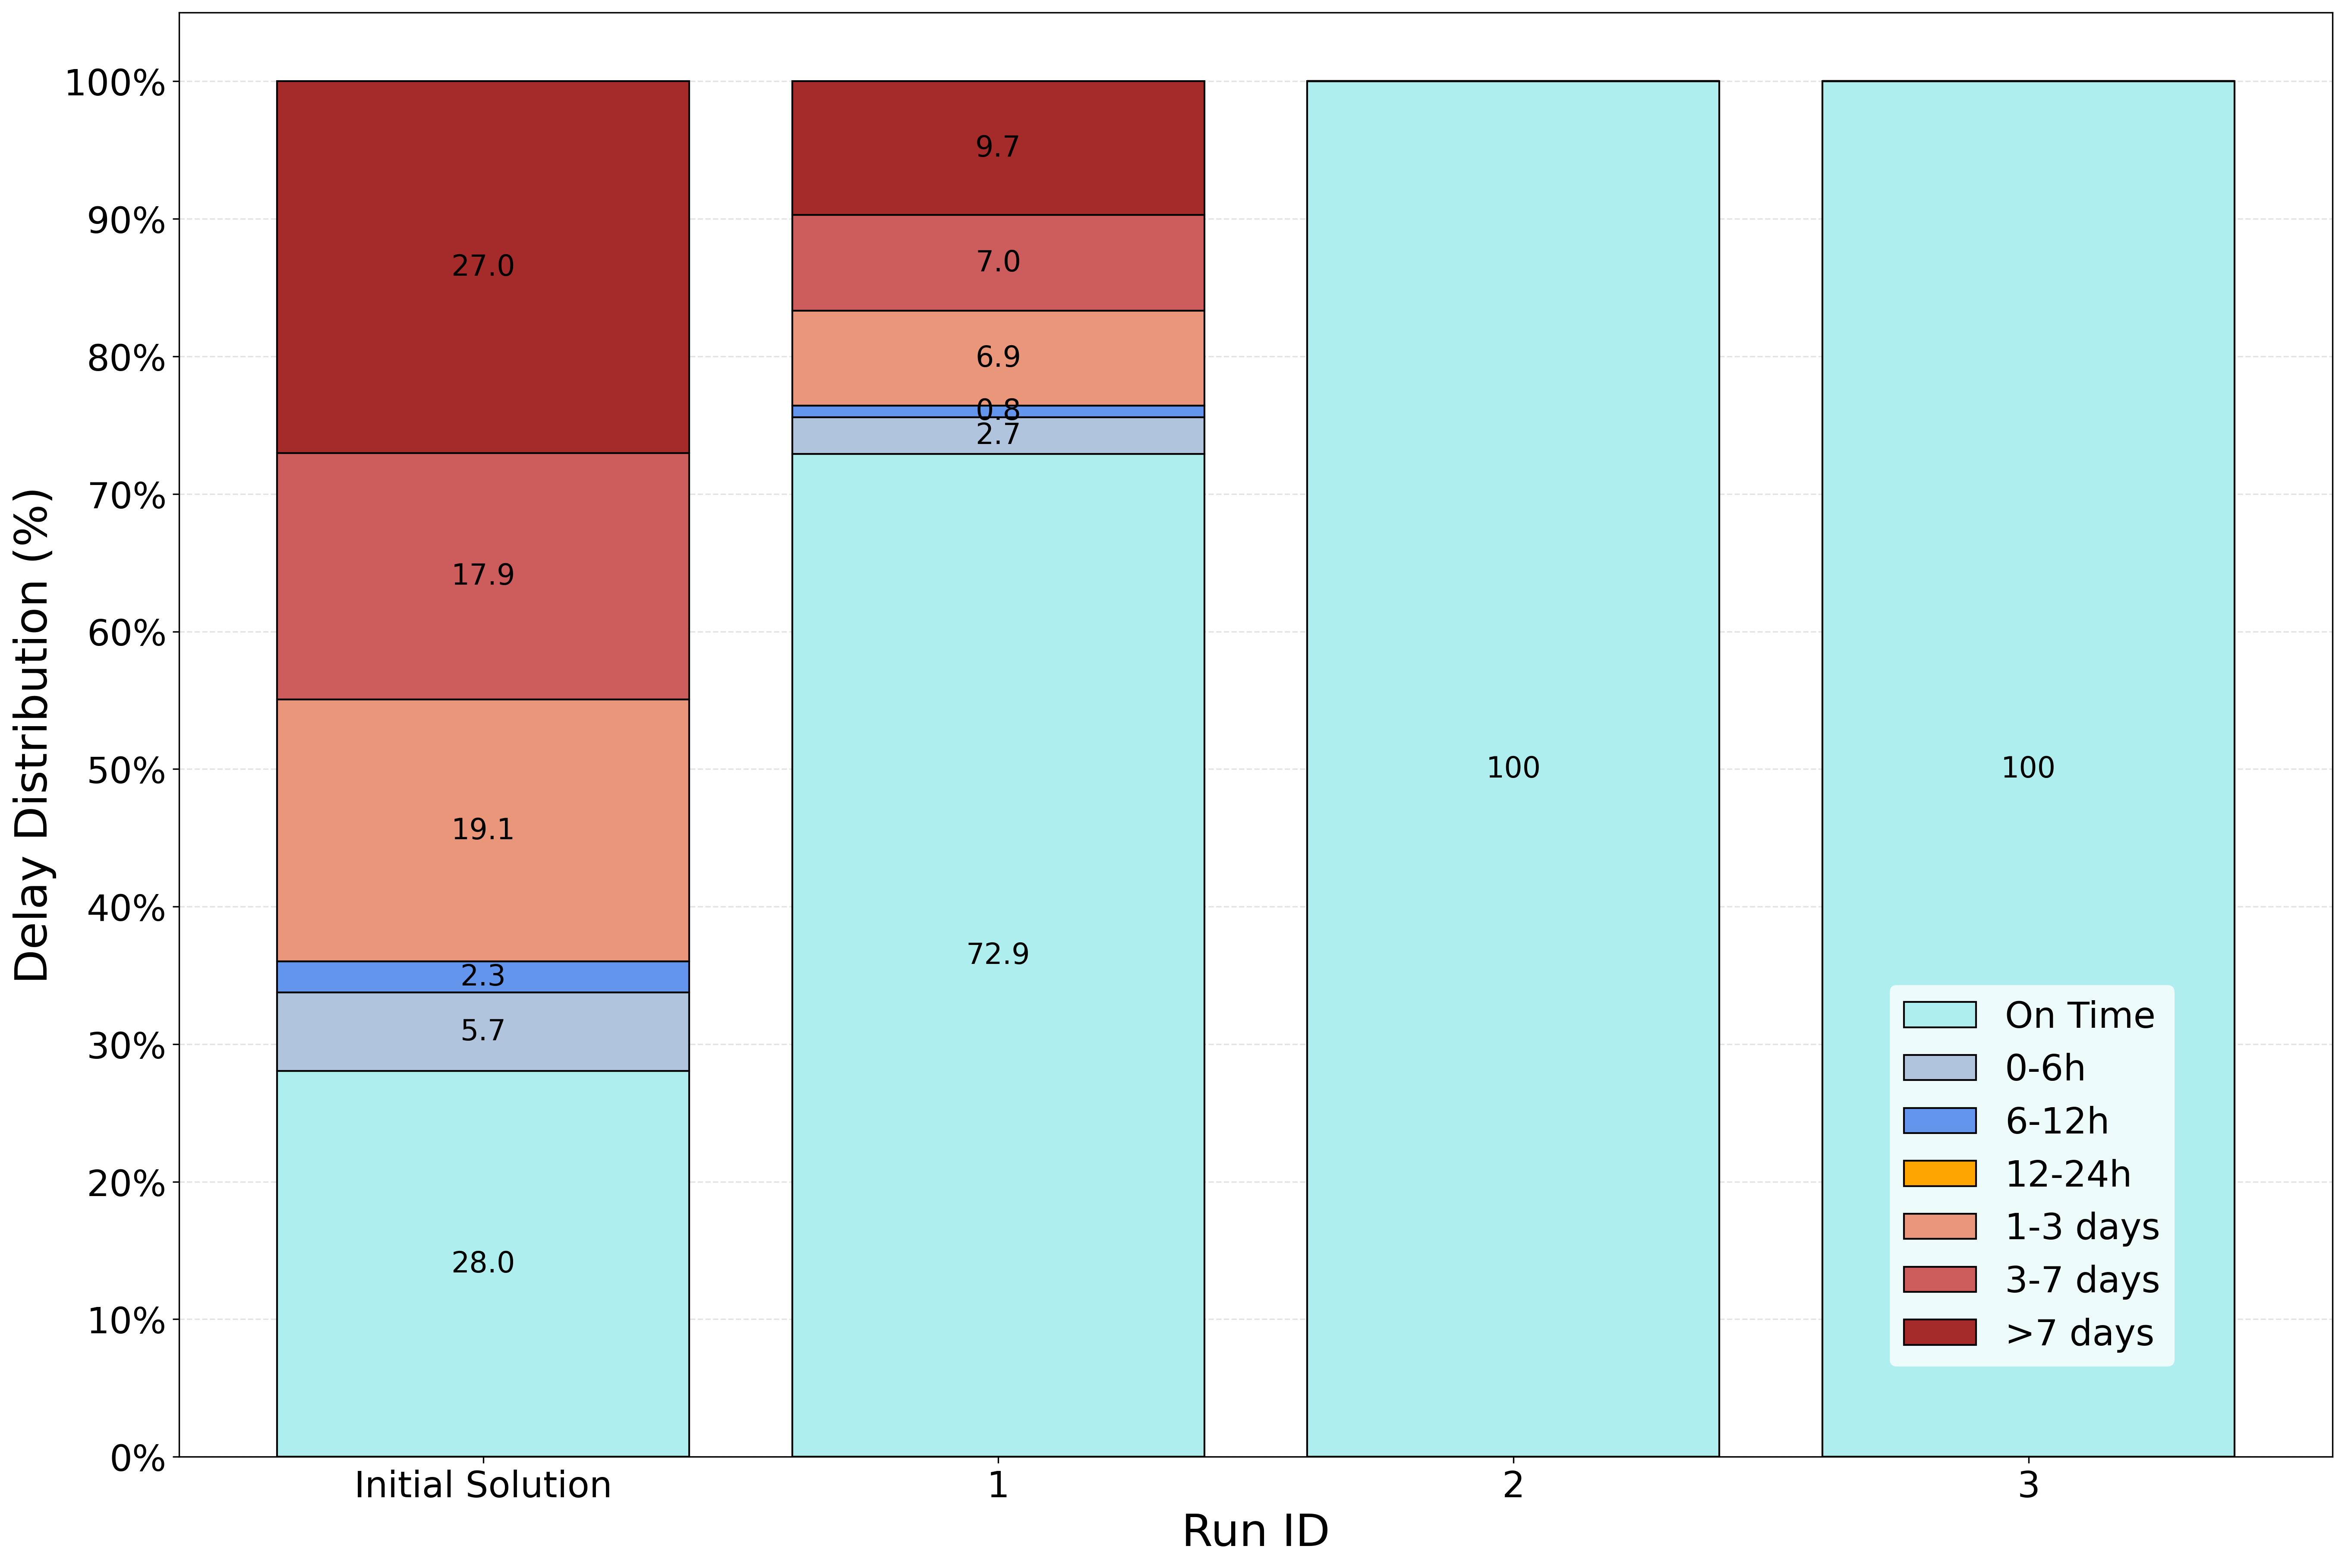

Saved: delay_distribution_kpi.png


In [3]:
from matplotlib.colors import to_rgb

delay_headers = [str(item) for item in delay_rows[0]]
run_ids = delay_headers[1:]
delay_categories = [str(row[0]) for row in delay_rows[1:]]
delay_values = [[float(value) for value in row[1:]] for row in delay_rows[1:]]

delay_colors = [
    "paleturquoise",
    "lightsteelblue",
    "cornflowerblue",
    "orange",
    "darksalmon",
    "indianred",
    "brown",
]

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
bottom = [0.0] * len(run_ids)

for category, values, color in zip(delay_categories, delay_values, delay_colors):
    bars = ax.bar(run_ids, values, bottom=bottom, color=color, edgecolor="black", linewidth=1.0, label=category)
    r, g, b = to_rgb(color)
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    for bar, value, base in zip(bars, values, bottom):
        if value > 0:
            label = f"{value:.1f}" if abs(value - round(value)) > 1e-9 else f"{int(round(value))}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                base + value / 2,
                label,
                ha="center",
                va="center",
                fontsize=16,
                color="black",
            )
    bottom = [base + value for base, value in zip(bottom, values)]

ax.set_xlabel("Run ID", fontsize=25)
ax.set_ylabel("Delay Distribution (%)", fontsize=25)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=20)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 10))
ax.legend(loc="lower right", fontsize=20, frameon=True, facecolor="white", edgecolor="none",bbox_to_anchor=(0.935, 0.05))



delay_png = BASE_DIR / "delay_distribution_kpi.png"
fig.savefig(delay_png, bbox_inches="tight")
plt.show()

print(f"Saved: {delay_png.name}")

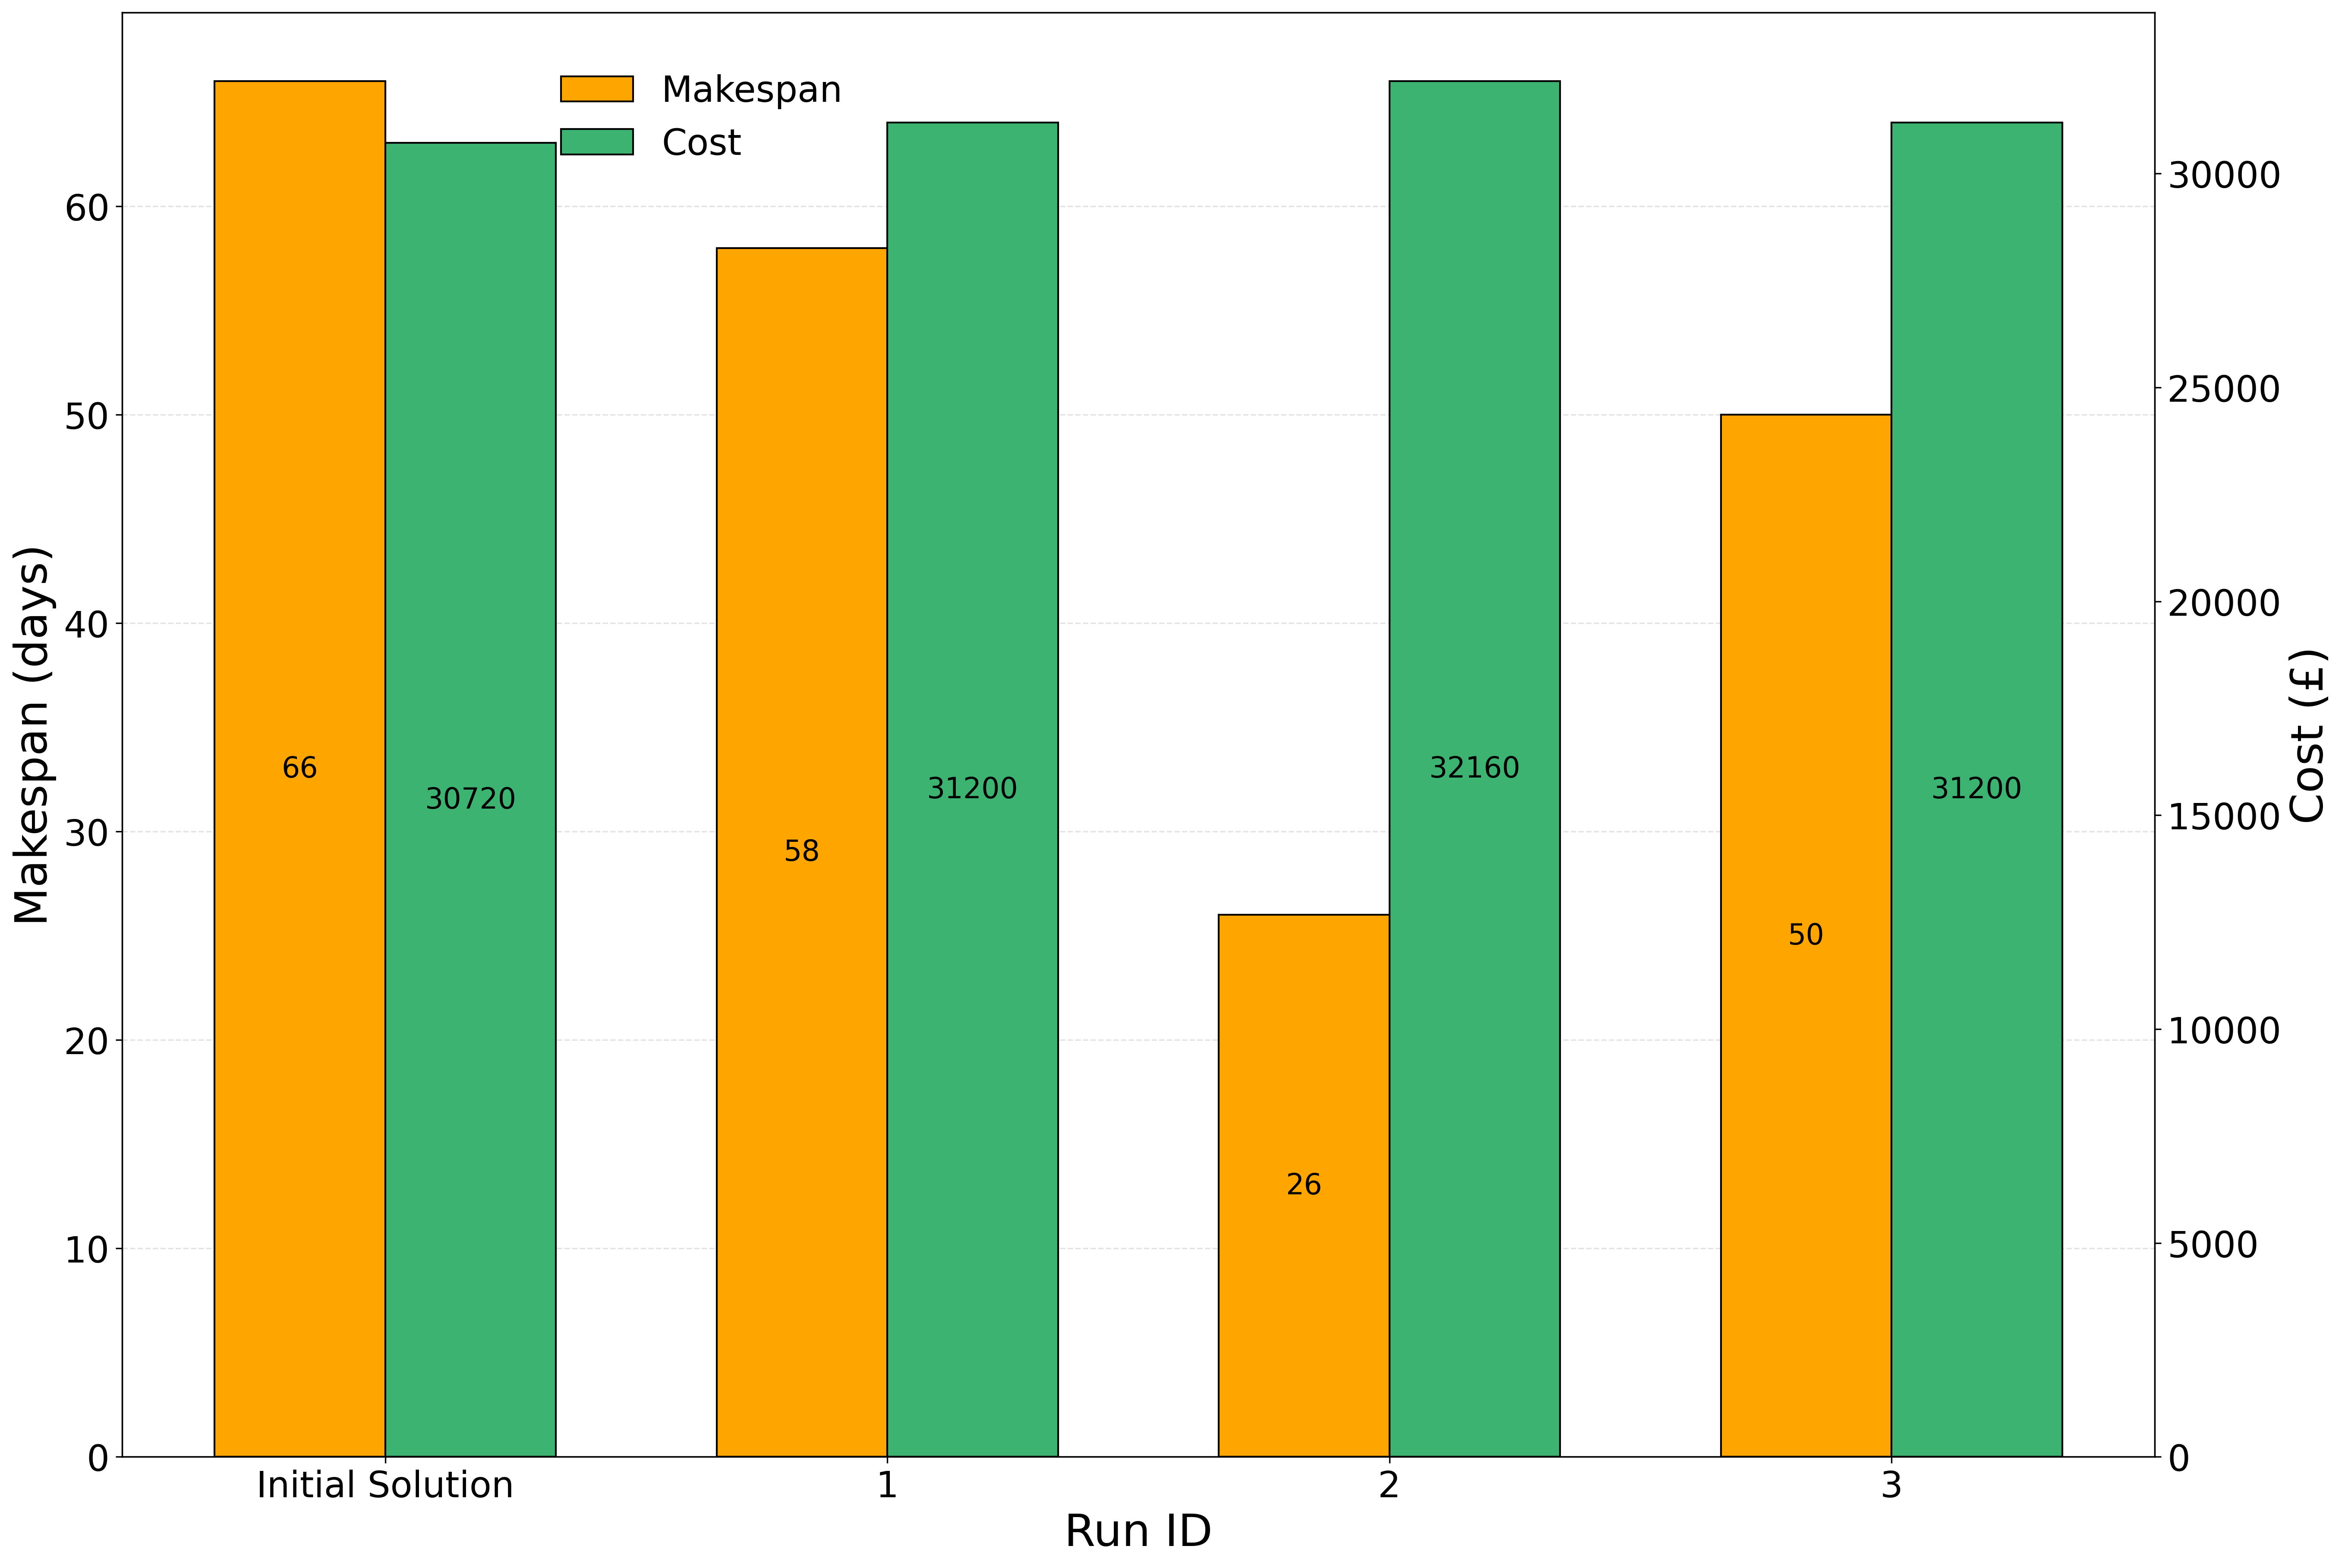

Saved: makespan_cost_kpi.png


In [4]:
makecost_headers = [str(item).strip() for item in makecost_rows[0]]
makecost_data = makecost_rows[1:]

run_ids_mc = [str(row[0]) for row in makecost_data]
makespan = [float(row[1]) for row in makecost_data]
cost = [float(row[2]) for row in makecost_data]

x = np.arange(len(run_ids_mc))
bar_width = 0.34

fig, ax_left = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
ax_right = ax_left.twinx()

bars_left = ax_left.bar(
    x - bar_width / 2,
    makespan,
    width=bar_width,
    color="orange",
    edgecolor="black",
    linewidth=1.0,
    label="Makespan",
)
bars_right = ax_right.bar(
    x + bar_width / 2,
    cost,
    width=bar_width,
    color="mediumseagreen",
    edgecolor="black",
    linewidth=1.0,
    label="Cost",
)

for bar, value in zip(bars_left, makespan):
    ax_left.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{int(value)}" if float(value).is_integer() else f"{value:.1f}",
        ha="center",
        va="center",
        fontsize=16,
        color="black",
    )

for bar, value in zip(bars_right, cost):
    ax_right.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{int(value)}" if float(value).is_integer() else f"{value:.1f}",
        ha="center",
        va="center",
        fontsize=16,
        color="black",
    )

ax_left.set_xticks(x)
ax_left.set_xticklabels(run_ids_mc)
ax_left.set_xlabel("Run ID", fontsize=25)
ax_left.set_ylabel("Makespan (days)", fontsize=25)
ax_right.set_ylabel("Cost (£)", fontsize=25)
ax_left.tick_params(axis="both", labelsize=20)
ax_left.tick_params(axis="y")
ax_right.tick_params(axis="y", labelsize=20)
ax_left.grid(axis="y", linestyle="--", alpha=0.35)
ax_left.set_axisbelow(True)

handles = [bars_left, bars_right]
labels = ["Makespan", "Cost"]
ax_left.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.2, 0.98), fontsize=20, frameon=True, facecolor="white", edgecolor="none")

makecost_png = BASE_DIR / "makespan_cost_kpi.png"
fig.savefig(makecost_png, bbox_inches="tight")
plt.show()

print(f"Saved: {makecost_png.name}")

In [6]:
station_rows = read_simple_xlsx(STATION_FILE)
station_headers = [str(item) for item in station_rows[0]]
station_data = station_rows[1:]

print("StationProcessing data")
print(" | ".join(station_headers))
for row in station_data:
    print(" | ".join(str(value) for value in row))

StationProcessing data
Run ID | 1 | 2 | 3 | 4
Initial | 916 | 946 | 0 | 0
1 | 910 | 940 | 0 | 0
2 | 421 | 460 | 506 | 448
3 | 596 | 711 | 257 | 283


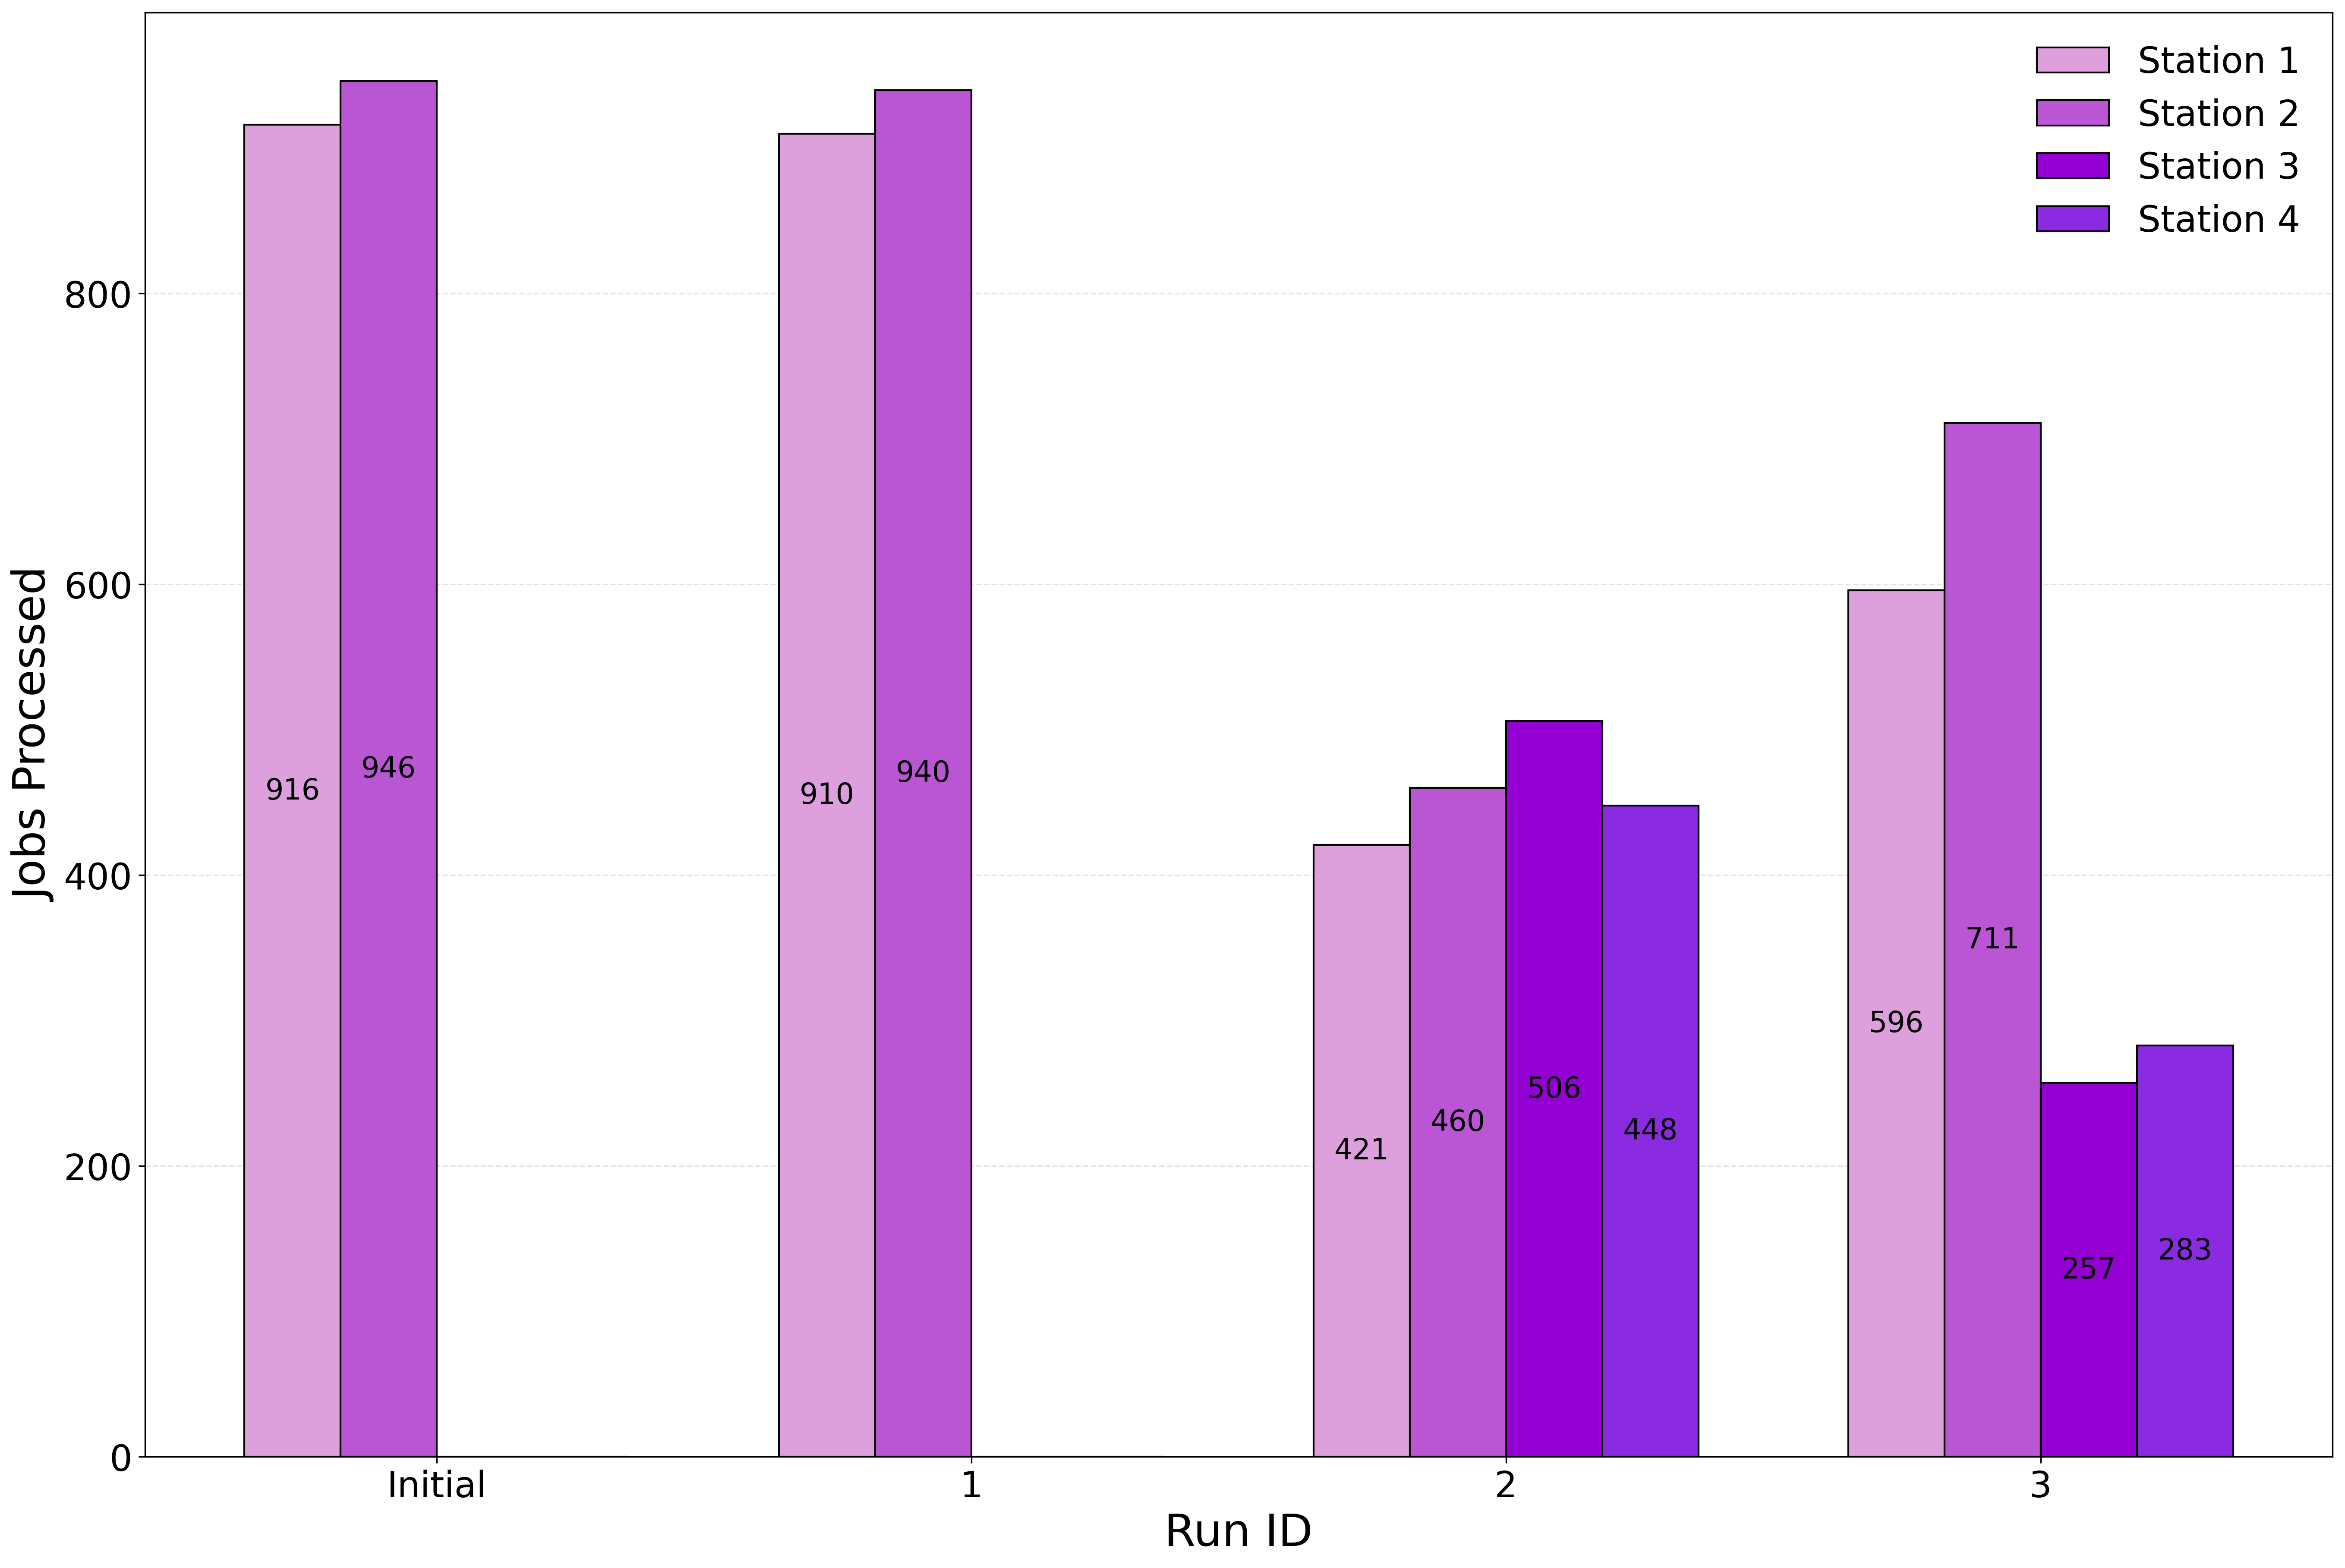

Saved: station_processing_kpi.png


In [7]:
from matplotlib.colors import to_rgb

station_run_ids = [str(row[0]) for row in station_data]
station_names = [f"Station {int(float(item))}" for item in station_headers[1:]]
station_matrix = [[float(value) for value in row[1:]] for row in station_data]
station_colors = ["plum", "mediumorchid", "darkviolet", "blueviolet"]

x = np.arange(len(station_run_ids))
bar_width = 0.18

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

for idx, (station_name, color) in enumerate(zip(station_names, station_colors)):
    values = [row[idx] for row in station_matrix]
    offset = (idx - 1.5) * bar_width
    bars = ax.bar(
        x + offset,
        values,
        width=bar_width,
        color=color,
        edgecolor="black",
        linewidth=1.0,
        label=station_name,
    )
    r, g, b = to_rgb(color)
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    for bar, value in zip(bars, values):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"{int(value)}" if float(value).is_integer() else f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=16,
                color="black",
            )

ax.set_xticks(x)
ax.set_xticklabels(station_run_ids)
ax.set_xlabel("Run ID", fontsize=25)
ax.set_ylabel("Jobs Processed", fontsize=25)
ax.tick_params(axis="both", labelsize=20)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=20, frameon=True, facecolor="white", edgecolor="none")

station_png = BASE_DIR / "station_processing_kpi.png"
fig.savefig(station_png, bbox_inches="tight")
plt.show()

print(f"Saved: {station_png.name}")